In [1]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
from deeptime.clustering import KMeans
from deeptime.clustering import RegularSpace
from deeptime.clustering import BoxDiscretization
import pandas as pd 
import pyemma

import mdtraj as md
import re, math, os, shutil, pickle

import warnings; warnings.simplefilter('ignore')
from collections import Counter

## Important Functions

In [2]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [3]:
# Define the directory path
directory = "cluster/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'cluster/' have been cleared.


## Load the data

In [4]:
## Load Distance Restraubt Data 
dist_path = f"traj_data/dis_state0.pkl"
dist = Data.load(dist_path)
dist = dist.array_list
print(f'dist.shape:{np.array(dist).shape}')

## Load Backbone Phi Omega angle 
omega_path = f"traj_data/omegas_state0.pkl"
omegas = Data.load(omega_path)
omegas = omegas.array_list
print(f'omegas.shape: {np.array(omegas).shape}')

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed

omega_indices = [r for r in residues_to_plot]
phi_indices   = [r + 1 for r in residues_to_plot]
psi_indices   = [r + 2 for r in residues_to_plot]
chi1_indices  = [r + 3 for r in residues_to_plot]

for angle_indices in [omega_indices, psi_indices, chi1_indices]:
    omegas[:, angle_indices] = (omegas[:, angle_indices] + 90.0) % 360.0 - 90.0

feat_all = np.hstack([dist,omegas])
print('feat_all.shape', feat_all.shape)

dist.shape:(100005, 156)
omegas.shape: (100005, 36)
feat_all.shape (100005, 192)


## TICA

In [5]:
from deeptime.decomposition import TICA
tica = TICA(lagtime=1, dim=2) # create a tica estimator 

In [6]:
# Fit the tica estimator on data > feat_all 
tica.fit(feat_all)

TICA-6861565728:[{'dim': 2,
                 'epsilon': 1e-06,
                 'lagtime': 1,
                 'observable_transform': <deeptime.basis._monomials.Identity object at 0x197921690>,
                 'scaling': 'kinetic_map',
                 'var_cutoff': None}]

In [7]:
# obtain model 
model = tica.fetch_model()
# Create the projection data 
projection = model.transform(feat_all)
print(projection.shape)

(100005, 2)


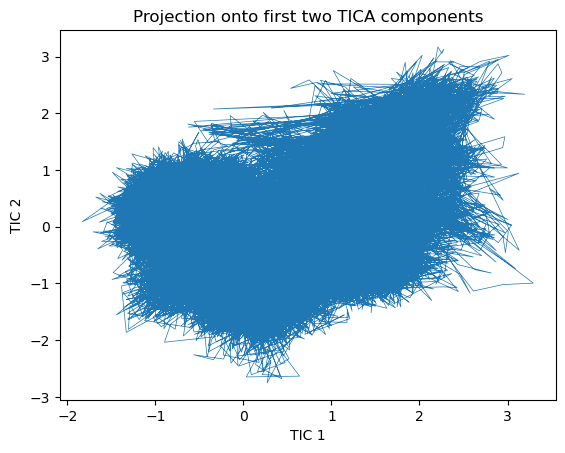

In [8]:
plt.plot(projection[:, 0], projection[:, 1], lw=0.5)
plt.xlabel('TIC 1')
plt.ylabel('TIC 2')
plt.title('Projection onto first two TICA components')
plt.show()

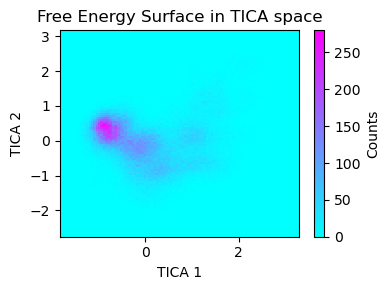

In [9]:

x = projection[:, 0]
y = projection[:, 1]

plt.figure(figsize=(4, 3))
plt.hist2d(x, y, bins=100, cmap='cool')
plt.colorbar(label='Counts')
plt.xlabel('TICA 1')
plt.ylabel('TICA 2')
plt.title('Free Energy Surface in TICA space')
plt.tight_layout()
plt.show()


## Clustering

In [11]:
from deeptime.clustering import MiniBatchKMeans

n_clusters = 10
estimator = MiniBatchKMeans(
    n_clusters=n_clusters,  # number of cluster centers
    max_iter=100,  # maximum number of passes over full dataset when calling fit()
    batch_size=327,  # sample size when drawing samples in fit()
    init_strategy='kmeans++',  # initialization strategy
    n_jobs=1
)

In [12]:
clustering_tica = estimator.fit(projection).fetch_model()
assignments = clustering_tica.transform(projection)
#print(np.unique(assignments)) # Print assignment labels 

# Find the cluster centers
cluster_centers = clustering_tica.cluster_centers

In [22]:
## Calcuate the percentage of each assignments 

# count the number of each cluter 
counts = Counter(assignments)
#print(counts)

# Sort the counts 
sorted_counts = dict(sorted(counts.items()))
total_counts = sum(counts.values())
cluster = []

for label, frequency in sorted_counts.items():    
    precentage = (frequency / total_counts) * 100 
    cluster.append(precentage)
    print(f"Assignment {label}: {frequency}, {precentage:.4g}%")


top_n = 10 # Select number of most populated frame 
# Sort clusters by frequency in descending order
top = sorted(sorted_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]

print(f"Top {top_n} most populated clusters:")
for label, count in top:
    percentage = (count / total_counts) * 100
    print(f"Assignment {label}: {count} frames, {percentage:.4g}%")

Assignment 0: 11880, 11.88%
Assignment 1: 2416, 2.416%
Assignment 2: 18552, 18.55%
Assignment 3: 4958, 4.958%
Assignment 4: 10259, 10.26%
Assignment 5: 13897, 13.9%
Assignment 6: 8053, 8.053%
Assignment 7: 6732, 6.732%
Assignment 8: 17928, 17.93%
Assignment 9: 5330, 5.33%
Top 10 most populated clusters:
Assignment 2: 18552 frames, 18.55%
Assignment 8: 17928 frames, 17.93%
Assignment 5: 13897 frames, 13.9%
Assignment 0: 11880 frames, 11.88%
Assignment 4: 10259 frames, 10.26%
Assignment 6: 8053 frames, 8.053%
Assignment 7: 6732 frames, 6.732%
Assignment 9: 5330 frames, 5.33%
Assignment 3: 4958 frames, 4.958%
Assignment 1: 2416 frames, 2.416%


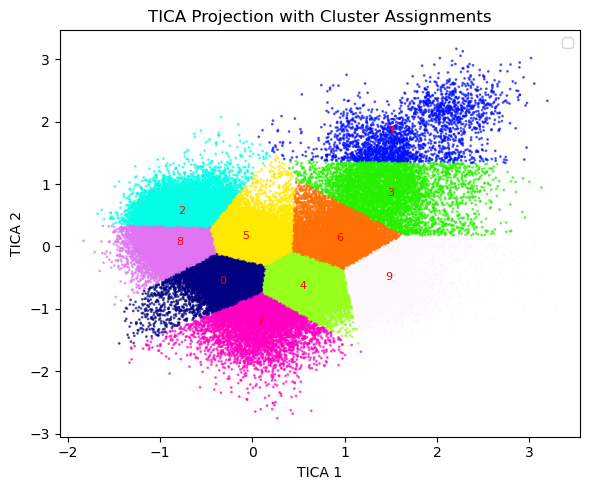

In [23]:
plt.figure(figsize=(6, 5))

# Plot all projected points colored by cluster assignment
plt.scatter(projection[:, 0], projection[:, 1], c=assignments, cmap='gist_ncar', s=1, alpha=0.6)

# Plot cluster centers
#plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], color='red', marker='x', s=100, label='Centers')

for i, (x, y) in enumerate(cluster_centers):
    plt.text(x, y, str(i), fontsize=8, color='red', ha='center', va='center')

plt.legend()
plt.xlabel("TICA 1")
plt.ylabel("TICA 2")
plt.title("TICA Projection with Cluster Assignments")
plt.tight_layout()
plt.show()


## Analysis the Top Populated Clusters

In [24]:
# Step 1: Get just the labels of the top clusters
top_labels = [label for label, _ in top]

# Step 2: For each top cluster, extract the corresponding rows from feat_all
top_cluster_data = {label: [] for label in top_labels}

for label in top_labels:
    # Find indices in 'assignments' that match this cluster
    indices = np.where(assignments == label)[0]

    # Get the feature vectors for these indices
    top_cluster_data[label] = feat_all[indices]

for label, data in top_cluster_data.items():
    print(f"Cluster {label}: {data.shape}")


Cluster 2: (18552, 192)
Cluster 8: (17928, 192)
Cluster 5: (13897, 192)
Cluster 0: (11880, 192)
Cluster 4: (10259, 192)
Cluster 6: (8053, 192)
Cluster 7: (6732, 192)
Cluster 9: (5330, 192)
Cluster 3: (4958, 192)
Cluster 1: (2416, 192)


### Distance analysis

In [25]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_10_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

[[24, 234, 5], [24, 235, 5], [25, 234, 5], [25, 235, 5], [137, 234, 5]]

In [26]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}


In [27]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

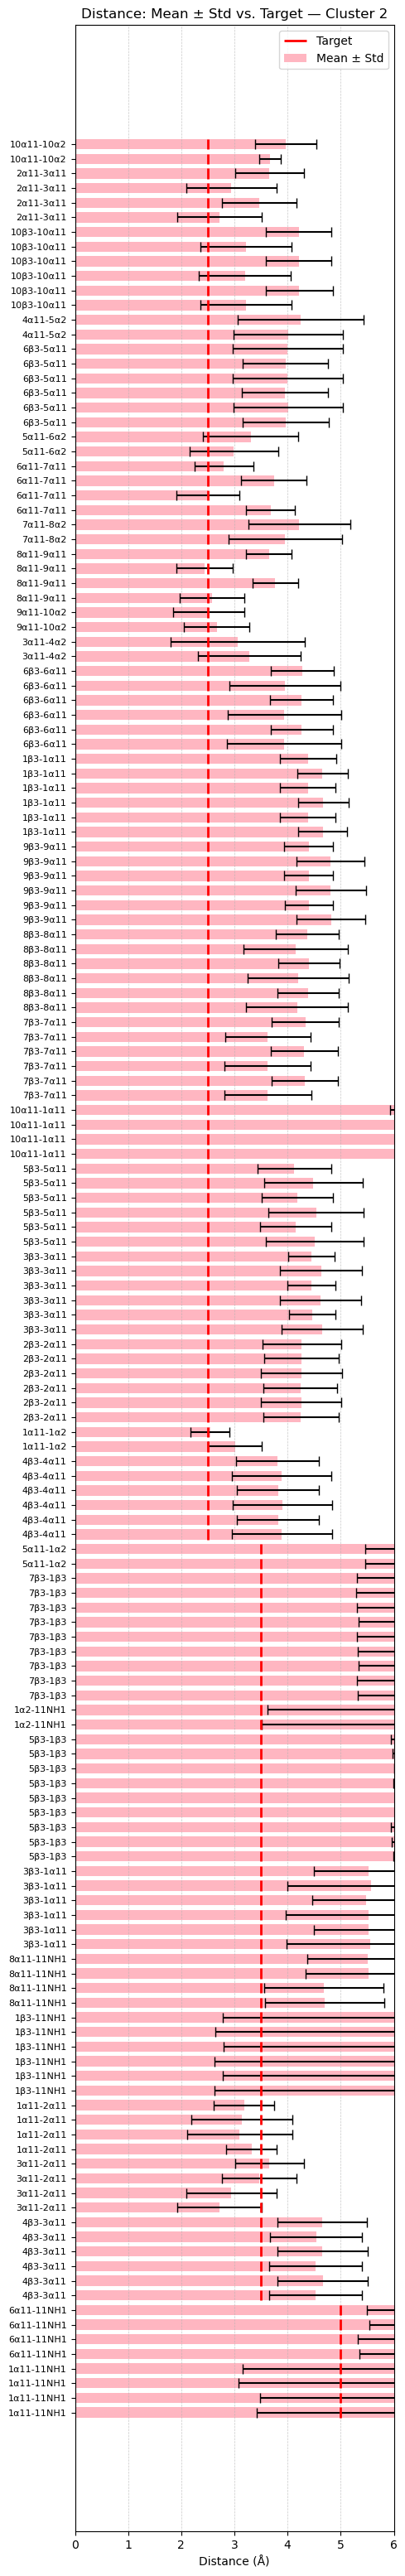

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

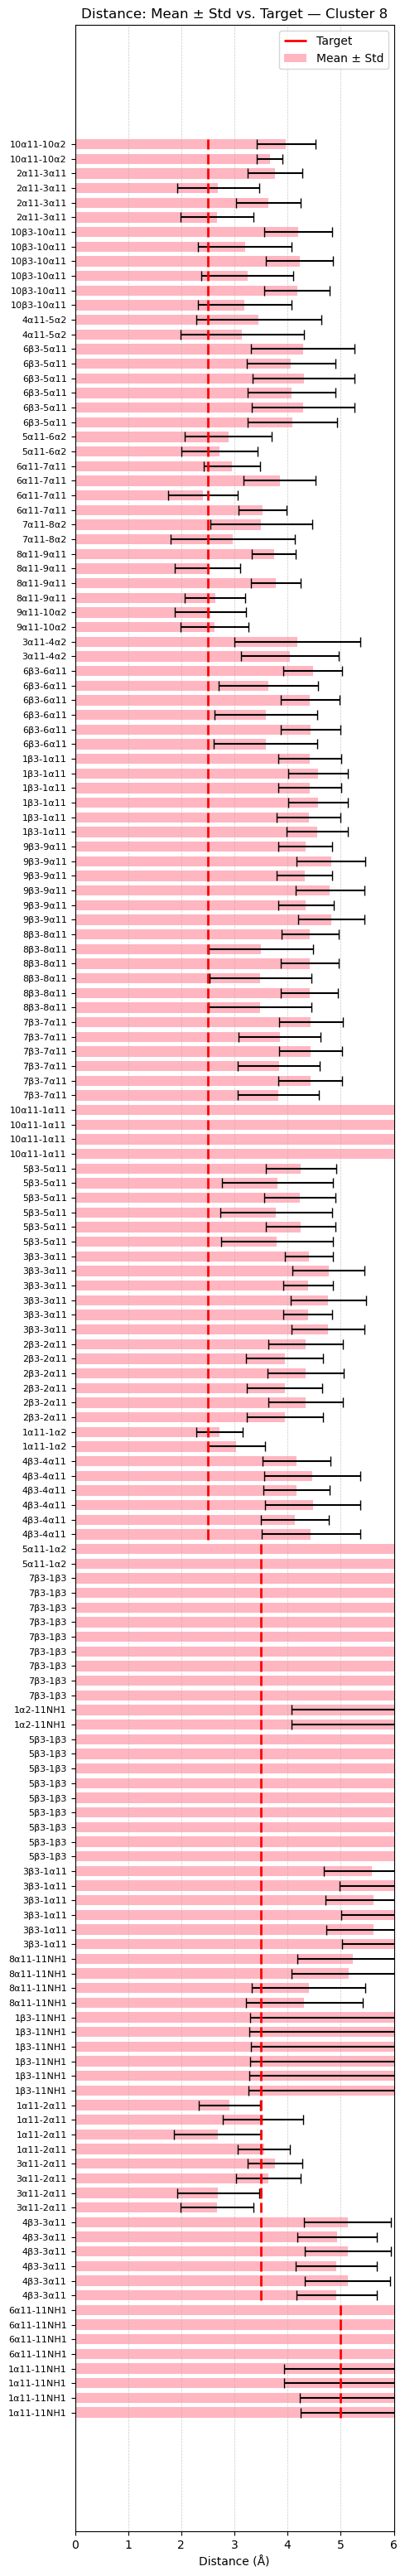

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

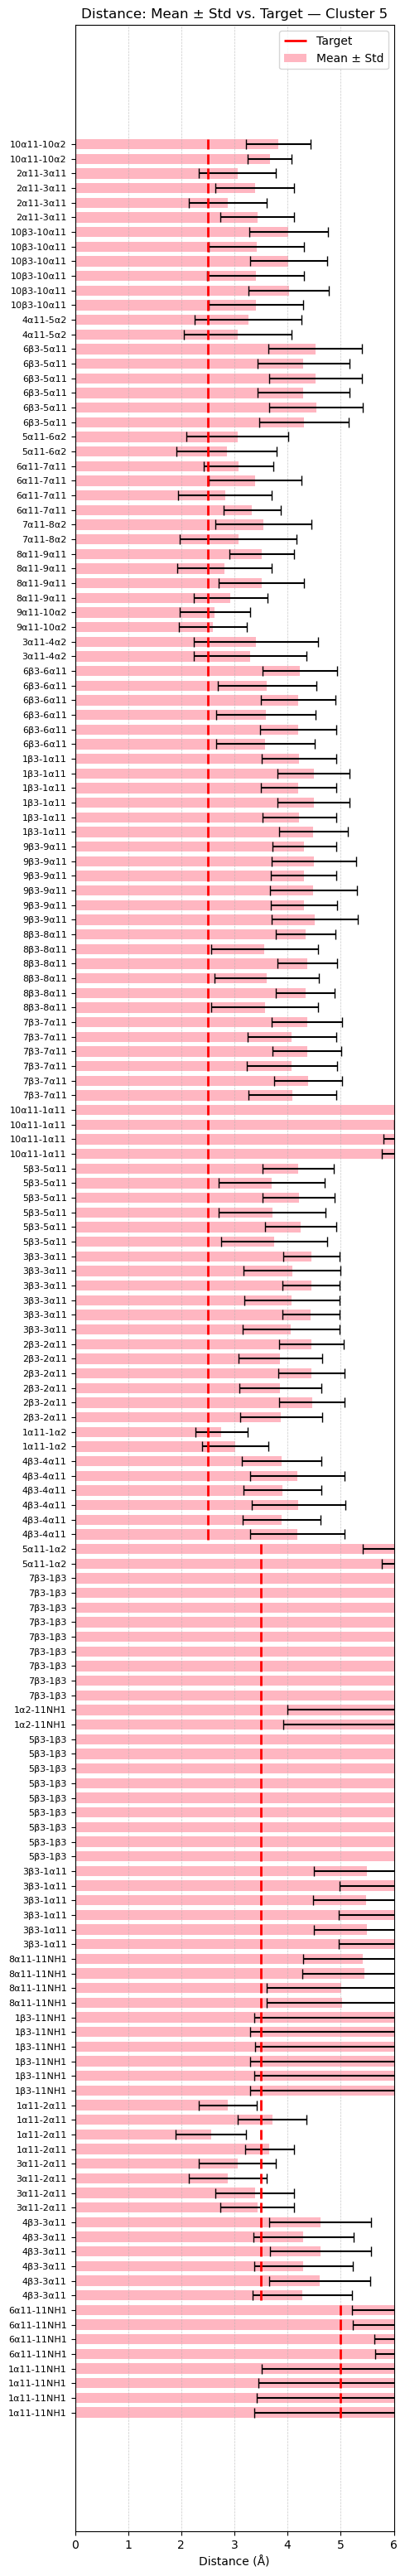

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

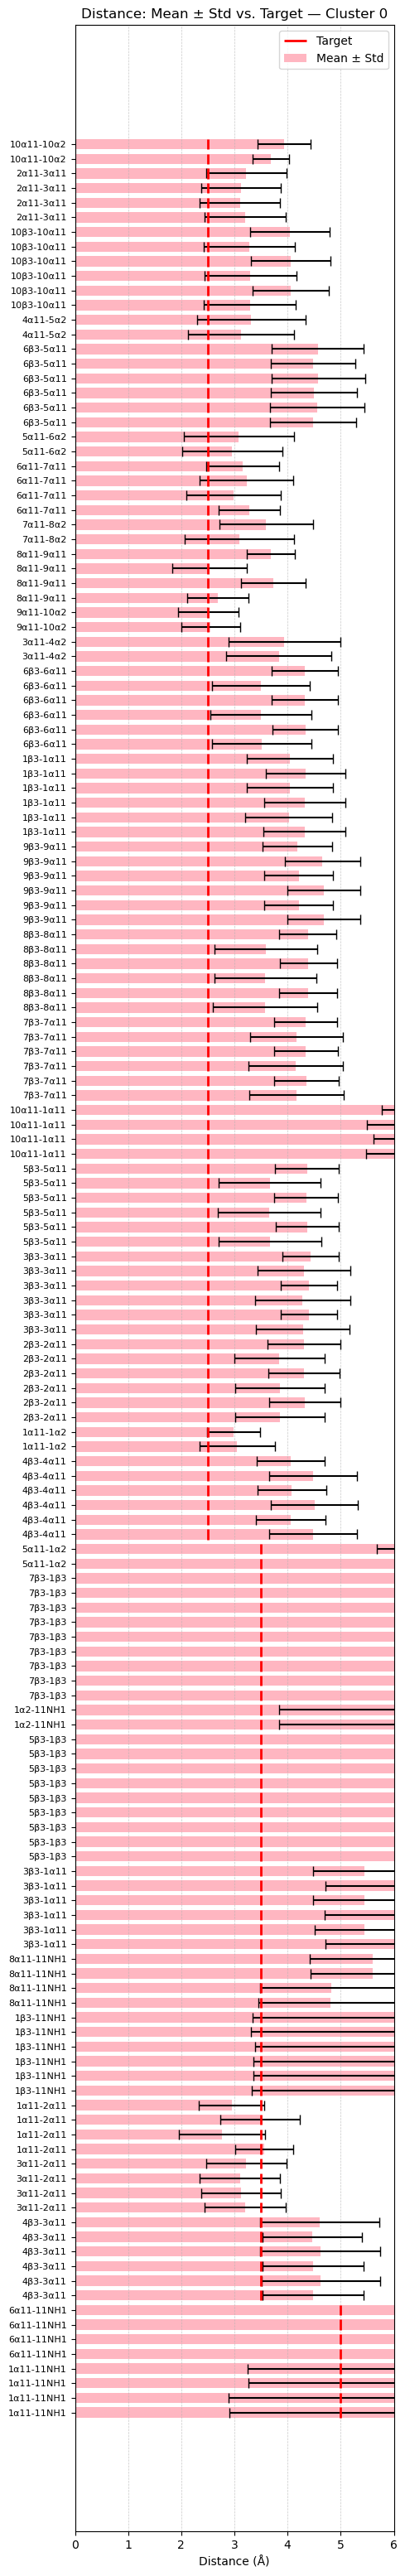

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

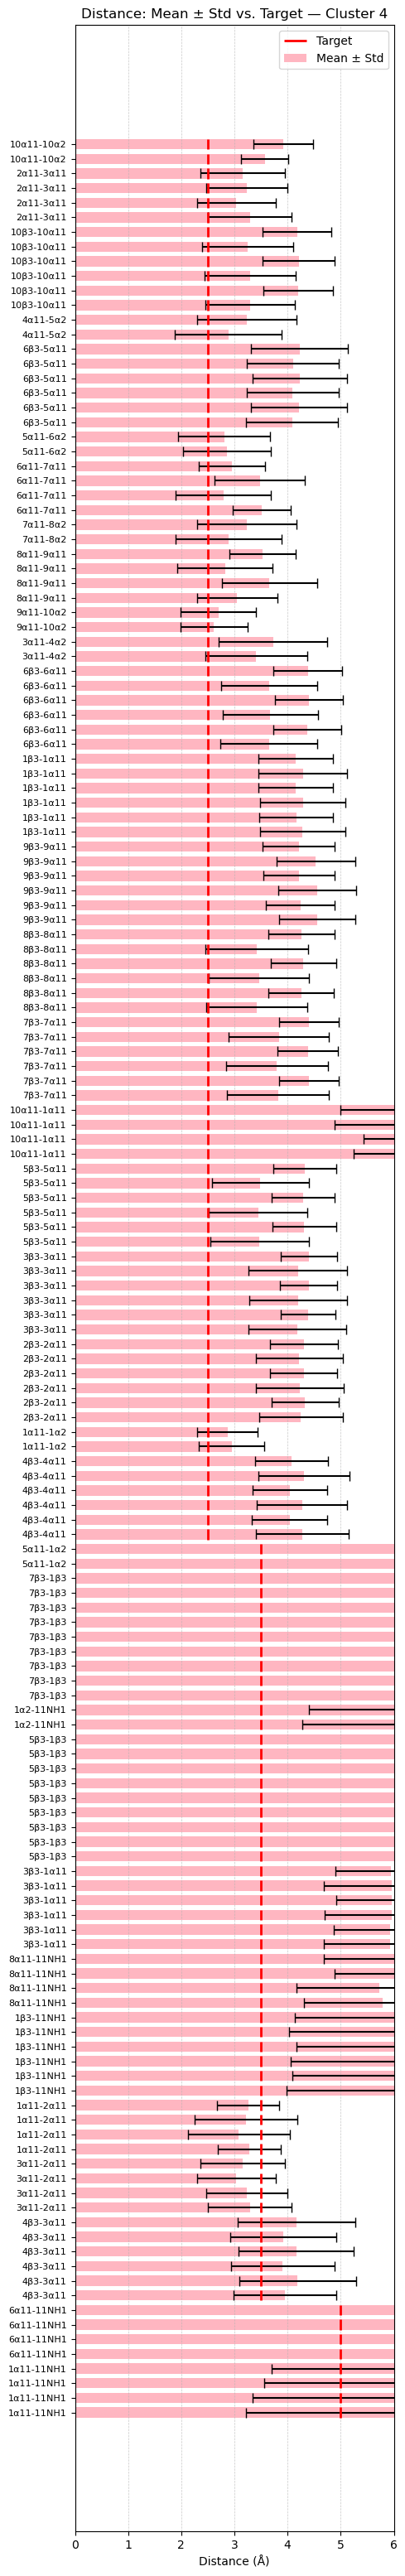

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

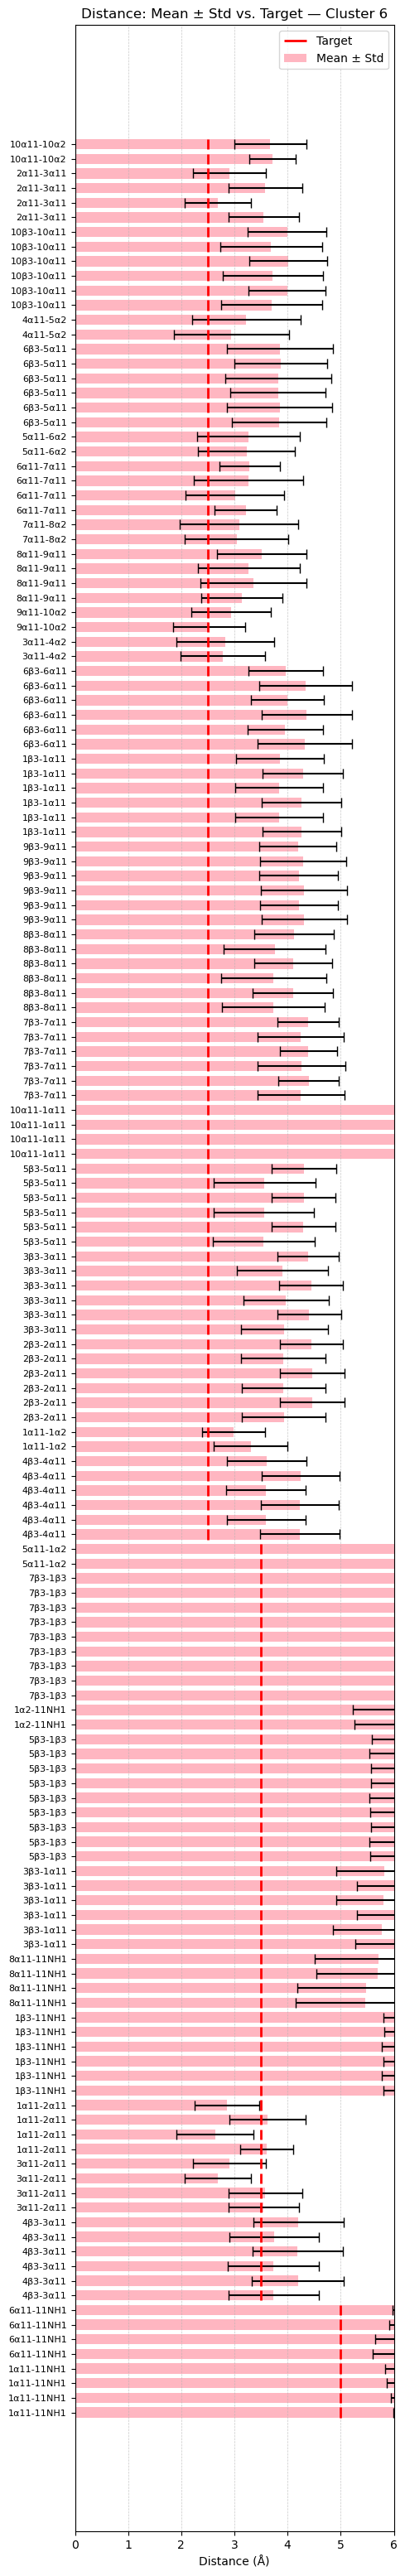

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

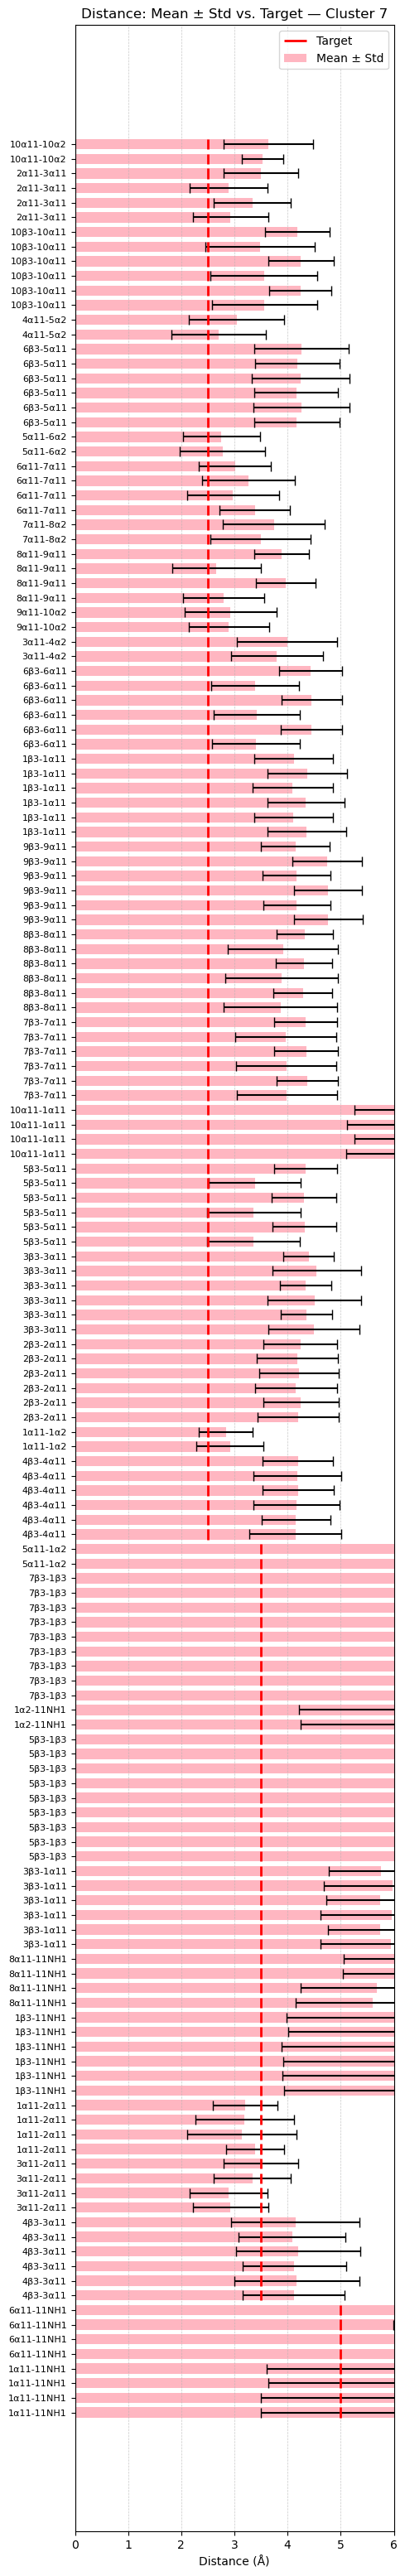

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

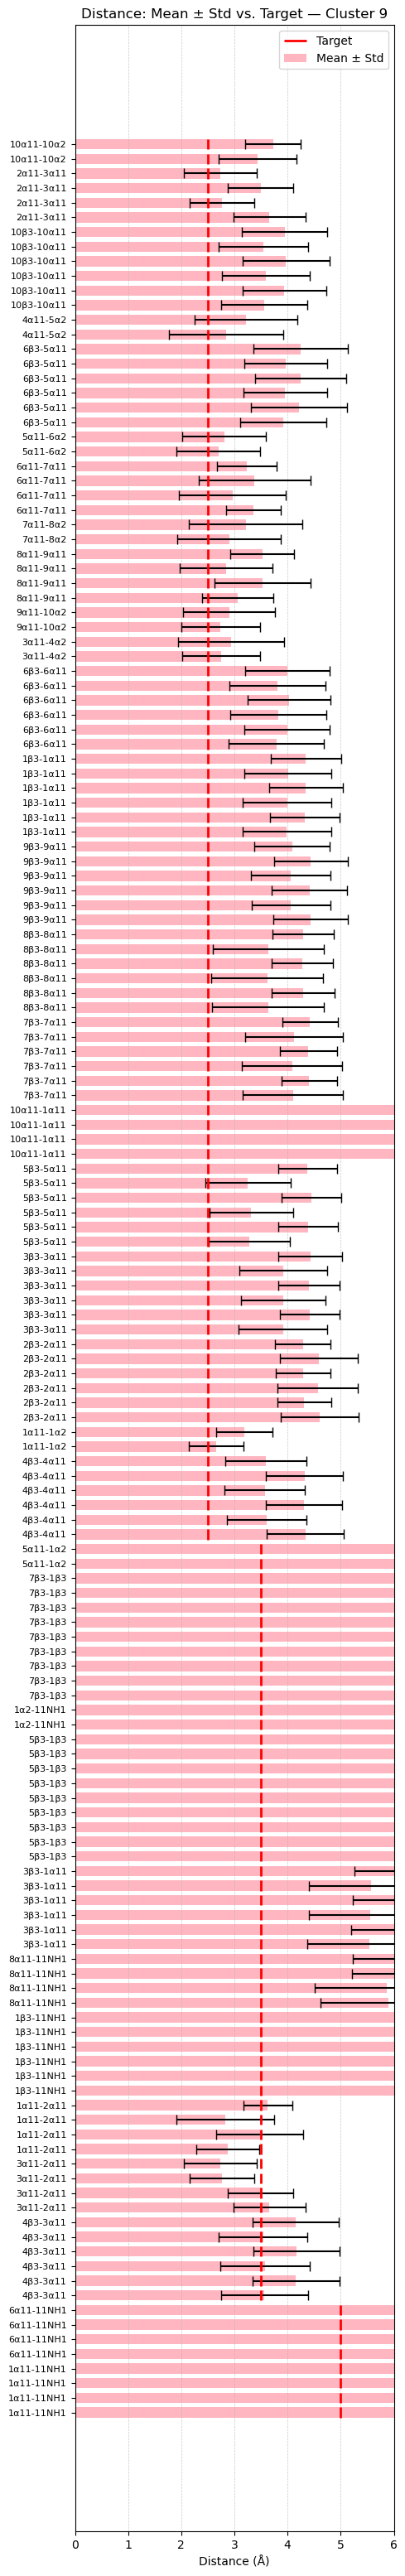

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

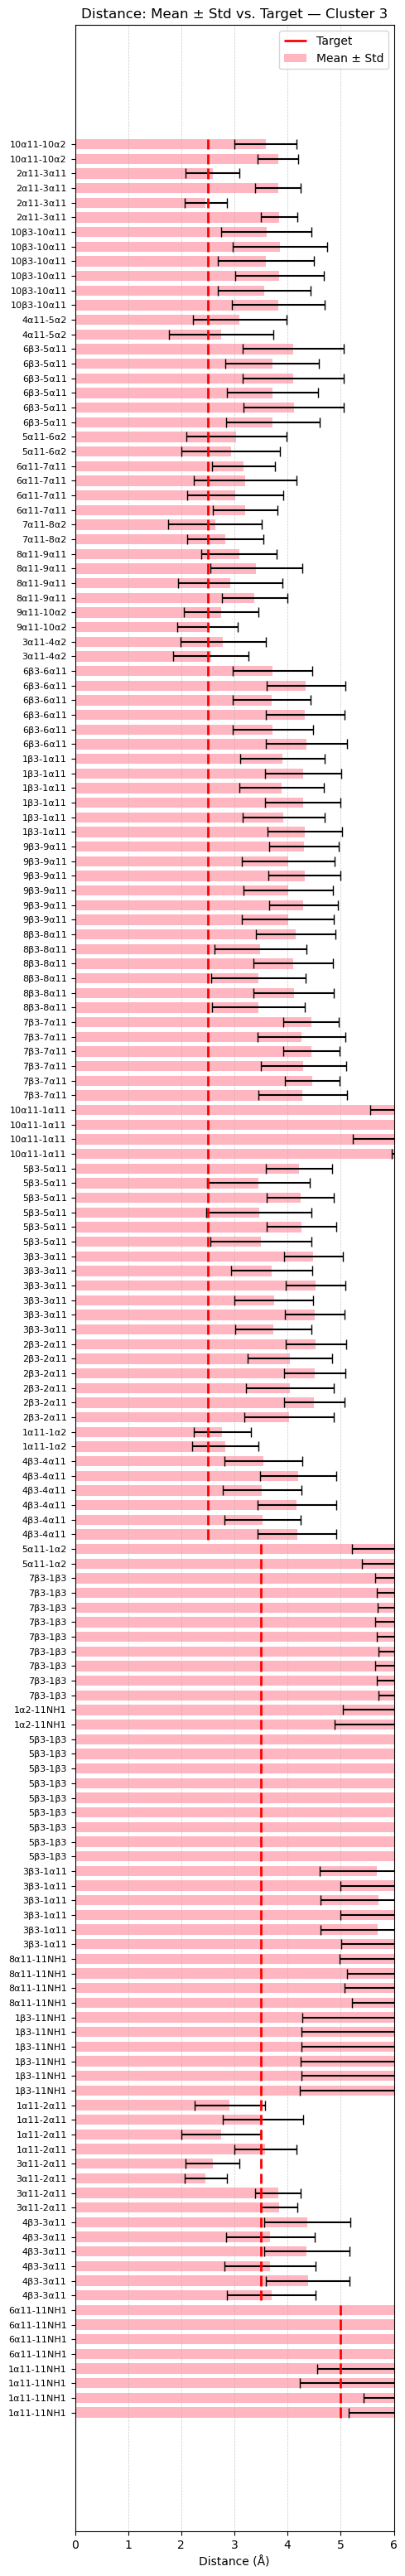

Label: H02 1 H12 23 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H12 23 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H12 (23), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN1 233
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: H02 1 H13 24 - NH2 11 HN2 234
Residue 1: H02 1, Atom: H13 (24), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H10 136 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 11, Atom: HN2 (234), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN1 233
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 11, Atom: HN1 (233), Group: NH1
Label: R02 6 H11 137 - NH2 11 HN2 234
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue

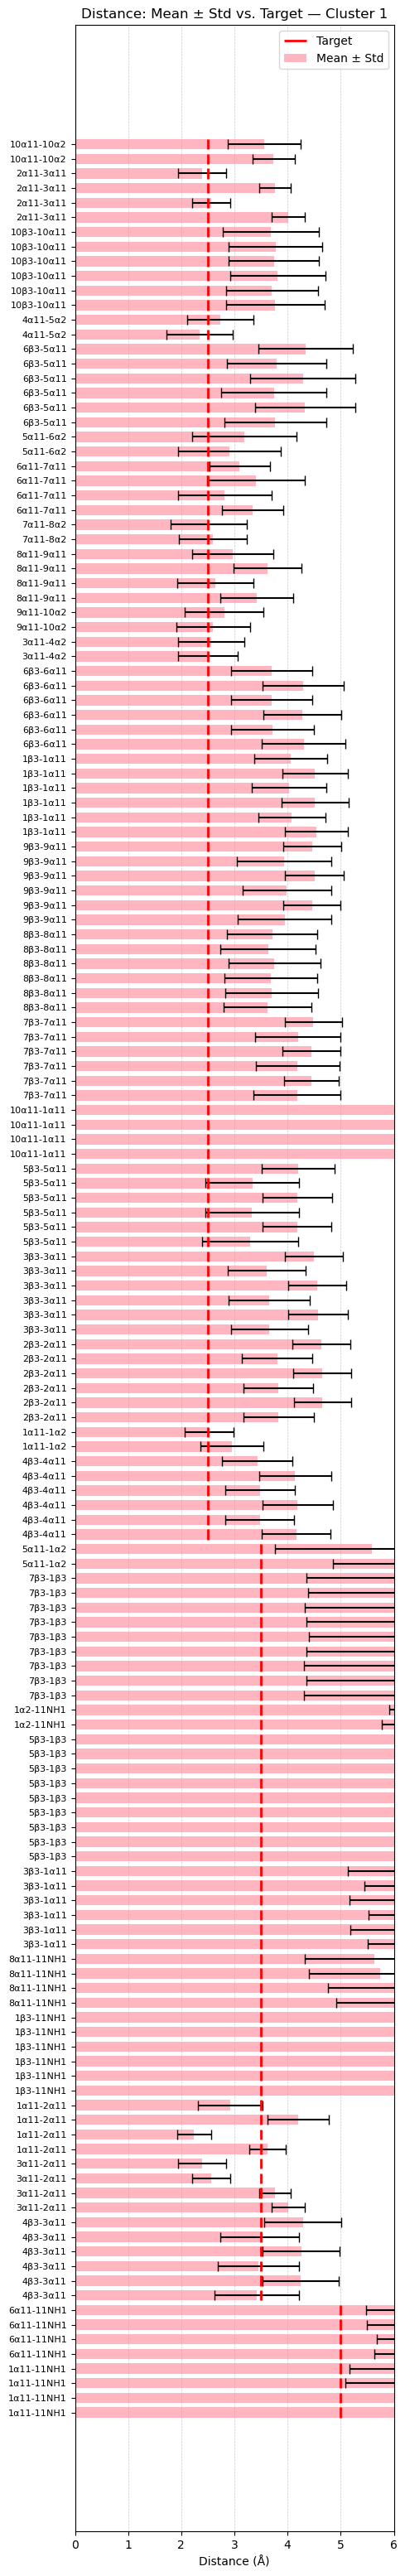

In [28]:
human_interpretable_label = True

grofile = "../nspe_10.amb2gmx/nspe_10_GMX.gro"

# Loop over top clusters instead of state numbers
for cluster_label, cluster_feat in top_cluster_data.items():
    means = []
    stds = []
    targets = []
    labels = []

    # Only use the first 192 columns (distance features)
    dist_feat = cluster_feat[:, :192]

    for i, (atom1, atom2, target) in enumerate(dist_res):
        dist = dist_feat[:, i]

        mean_val = np.mean(dist)
        std_val = np.std(dist)

        means.append(mean_val)
        stds.append(std_val)
        targets.append(target)

        # PyEMMA labels
        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([[atom1_pyemma, atom2_pyemma]])
        label = feat.describe()[0]

        if human_interpretable_label:
            labels.append(translate_pyemma_label(label=label))
        else:
            labels.append(label)

    # Convert to numpy arrays
    means = np.array(means)
    stds = np.array(stds)
    targets = np.array(targets)

    y = np.arange(len(labels))
    height = 0.7

    plt.figure(figsize=(5, max(6, len(labels) * 0.2)))

    # Plot bars: mean ± std
    plt.barh(y, means, height=height, xerr=stds, capsize=4, label='Mean ± Std', color='lightpink')

    # Target distances
    target_label_plotted = False
    for yi, ti in zip(y, targets):
        if not target_label_plotted:
            plt.vlines(ti, yi - height / 2, yi + height / 2, colors='red', linestyles='-', linewidth=2, label='Target')
            target_label_plotted = True
        else:
            plt.vlines(ti, yi - height / 2, yi + height / 2, colors='red', linestyles='-', linewidth=2)

    plt.yticks(y, labels, fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Distance: Mean ± Std vs. Target — Cluster {cluster_label}")
    #plt.xlim(0, max(np.max(means + stds), np.max(targets)) * 1.1)
    plt.xlim(0, 6)
    plt.legend()
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


### Analysis Dihedral

In [29]:
def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel, labelpad=4)
        ax.set_ylabel(ylabel, labelpad=4)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(nrows, ncols, figsize=(1.5 * ncols, 0.7 * nrows), sharex='col')
        axes = np.atleast_2d(axes)

        fig.suptitle(f'Nspe_10 — State {state_idx} REMD (Distances Restrainted OFF)', fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        #fig.tight_layout()
        fig.subplots_adjust(wspace=0.5)  # adds horizontal space between columns
        plt.show()



Plotting Cluster 2 with 18552 frames


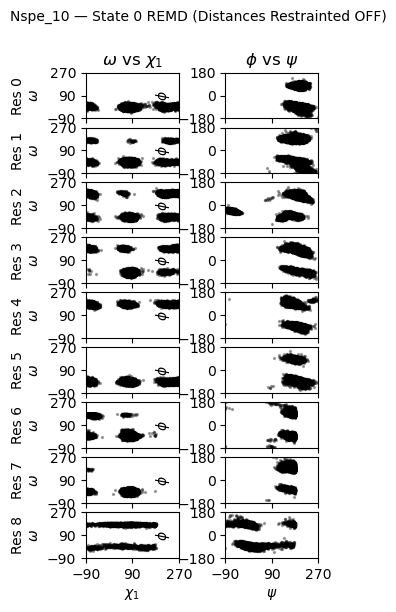

Plotting Cluster 8 with 17928 frames


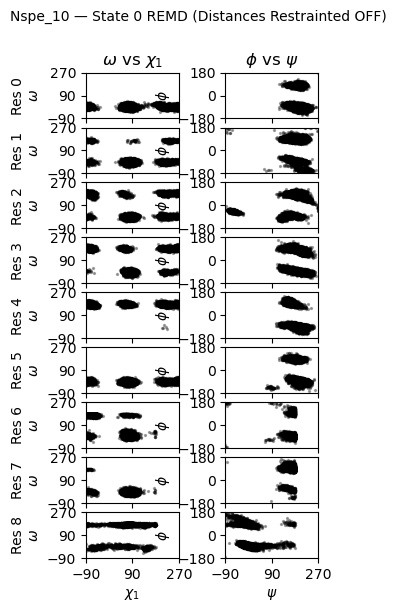

Plotting Cluster 5 with 13897 frames


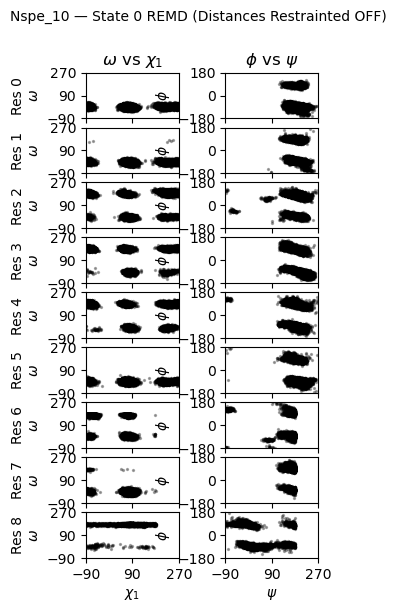

Plotting Cluster 0 with 11880 frames


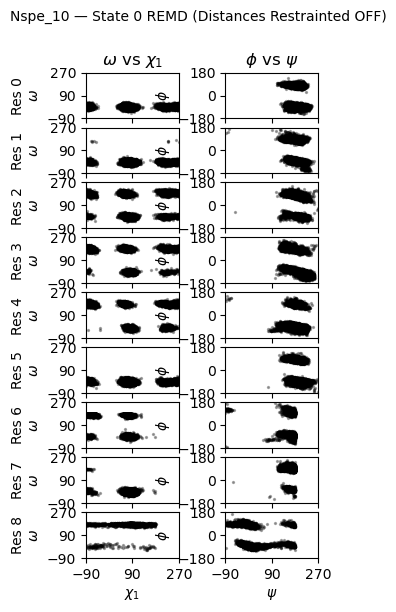

Plotting Cluster 4 with 10259 frames


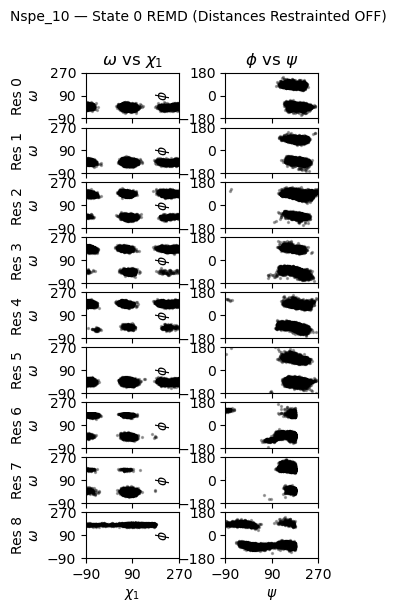

Plotting Cluster 6 with 8053 frames


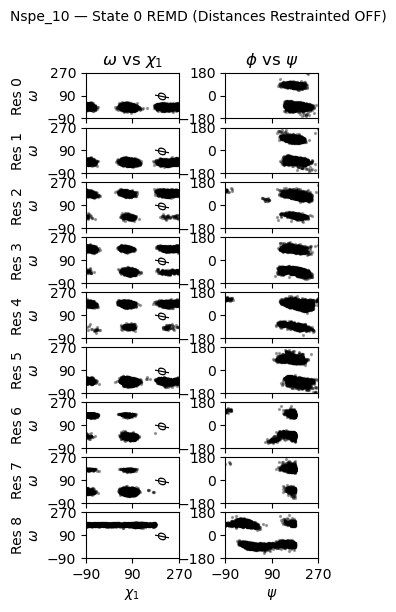

Plotting Cluster 7 with 6732 frames


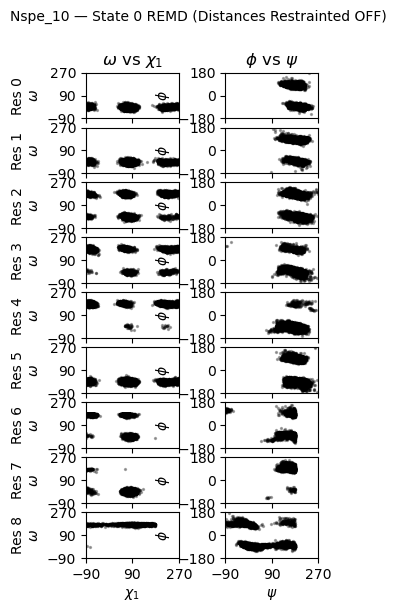

Plotting Cluster 9 with 5330 frames


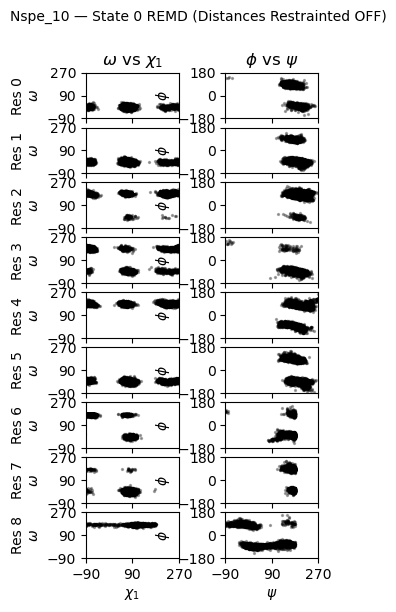

Plotting Cluster 3 with 4958 frames


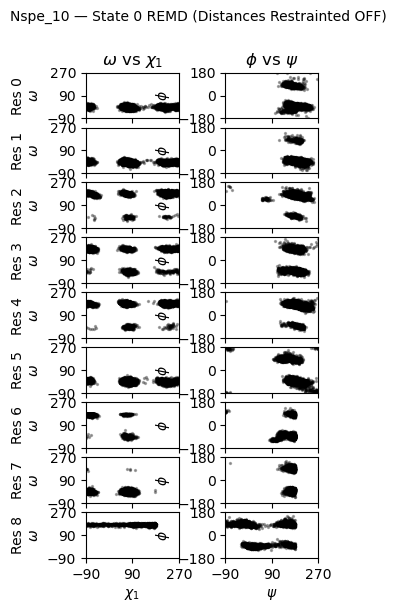

Plotting Cluster 1 with 2416 frames


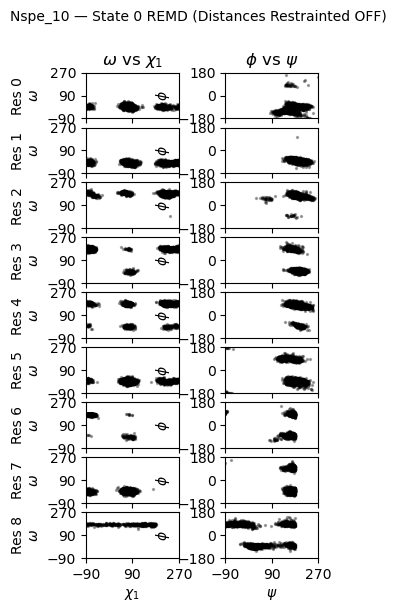

In [30]:
# Available options for angles_to_plot:

# "phi_psi"      # Plot ψ vs φ
# "omega_phi"    # Plot φ vs ω
# "omega_psi"    # Plot ψ vs ω
# "omega_chi1"   # Plot χ₁ vs ω
# "phi_chi1"     # Plot χ₁ vs φ
# "psi_chi1"     # Plot χ₁ vs ψ

residues_to_plot = np.arange(0, 36, 4).tolist()  # Modify if needed

angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

for label, data in top_cluster_data.items():
    omega_cluster = data[:, -36:]  # ← Last 24 columns are dihedrals
    omega_input = omega_cluster[np.newaxis, :, :]  # Shape (1, n_frames, 24)

    print(f"Plotting Cluster {label} with {omega_cluster.shape[0]} frames")

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot
    )

## Sampling

In [33]:
# Define the directory path
directory = "sampling/"

# Check if the directory exists
if os.path.exists(directory):
    # Remove all contents of the directory
    shutil.rmtree(directory)
    # Recreate the empty directory
    os.makedirs(directory)
    print(f"All contents in '{directory}' have been cleared.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'sampling/' have been cleared.


In [34]:
sample_size = 5

# Create Cluster Dictionary
cluster = {assignment: [] for assignment in np.unique(assignments)}

# Store frame indices in each cluster
for index, assignment in enumerate(assignments):
    cluster[assignment].append(index)

# Create Frame Dictionary (to store sampled frames)
frames = {assignment: [] for assignment in np.unique(assignments)}

# Number of clusters
n_clusters = len(np.unique(assignments))

# Randomly sample 50 frames from each cluster (or fewer if not enough)
for i in range(n_clusters):
    if len(cluster[i]) > 0:
        sample_size = min(sample_size, len(cluster[i]))
        indices = np.random.choice(cluster[i], size=sample_size, replace=False)
        frames[i] = indices.tolist()  # ← Store sampled indices

print('Sampled frames per cluster:', {k: len(v) for k, v in frames.items()})

Sampled frames per cluster: {0: 5, 1: 5, 2: 5, 3: 5, 4: 5, 5: 5, 6: 5, 7: 5, 8: 5, 9: 5, 10: 5, 11: 5, 12: 5, 13: 5, 14: 5, 15: 5, 16: 5, 17: 5, 18: 5, 19: 5, 20: 5, 21: 5, 22: 5, 23: 5, 24: 5, 25: 5, 26: 5, 27: 5, 28: 5, 29: 5, 30: 5, 31: 5, 32: 5, 33: 5, 34: 5, 35: 5, 36: 5, 37: 5, 38: 5, 39: 4, 40: 4, 41: 4, 42: 4, 43: 4, 44: 4, 45: 4, 46: 4, 47: 4, 48: 4, 49: 4, 50: 4, 51: 4, 52: 4, 53: 4, 54: 4, 55: 4, 56: 4, 57: 4, 58: 4, 59: 4, 60: 4, 61: 4, 62: 4, 63: 4, 64: 4, 65: 4, 66: 4, 67: 4, 68: 4, 69: 4, 70: 4, 71: 4, 72: 4, 73: 4, 74: 4, 75: 4, 76: 4, 77: 4, 78: 4, 79: 4, 80: 4, 81: 4, 82: 4, 83: 4, 84: 4, 85: 4, 86: 4, 87: 4, 88: 4, 89: 4, 90: 4, 91: 4, 92: 4, 93: 4, 94: 4, 95: 4, 96: 4, 97: 4, 98: 4, 99: 4}


In [35]:

HREX_dir = '../traj_remd'
run_num = 1 # How many run

trajs = []
HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]
for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"  
    xtcfile = f"{HREX_path}/state_0/HREMD.part0001_intact.xtc"
    grofile = f"../nspe_10.amb2gmx/nspe_10_GMX.gro"
    traj = md.load(xtcfile, top=grofile)
    trajs.append(traj)

# Concatenate trajectories
concatenated_trajs = md.join(trajs)

# Save sampled frames to new xtc files
for cluster in frames:
    sampling = concatenated_trajs[frames[cluster]]    
    sampling.save_xtc(f"sampling/sample_state_0_cluster{cluster}.xtc")
    sampling.save_pdb(f"sampling/sample_state_0_cluster{cluster}.pdb")
